**Data Exploration and Preparation**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


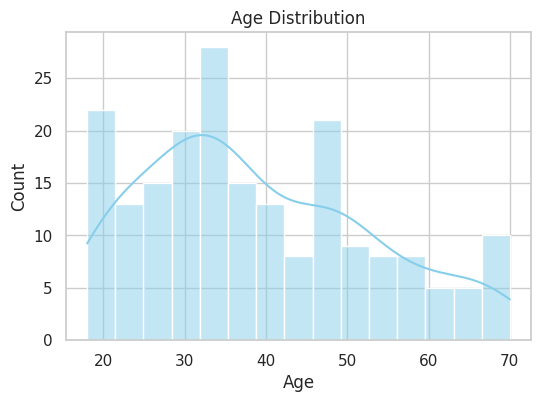

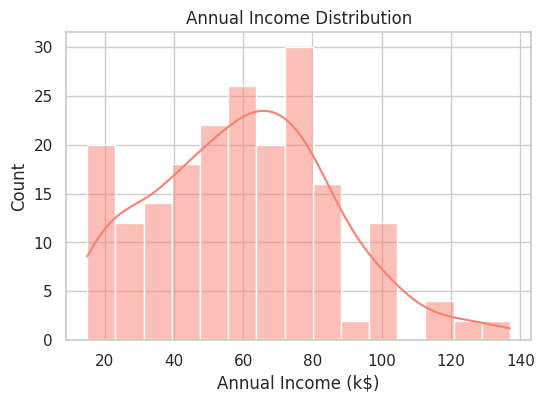

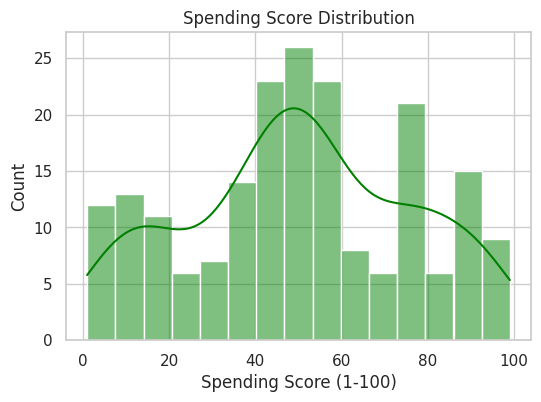

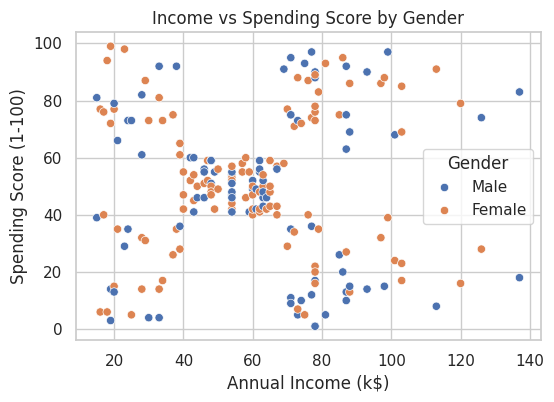

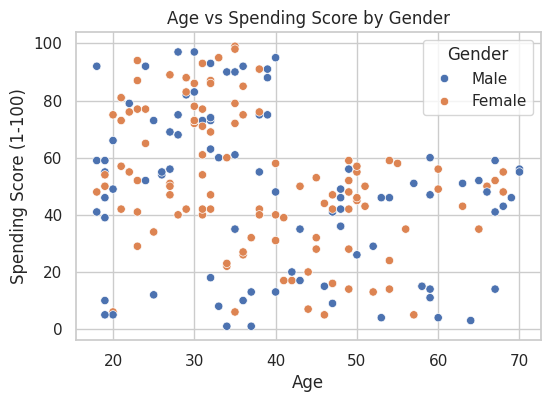

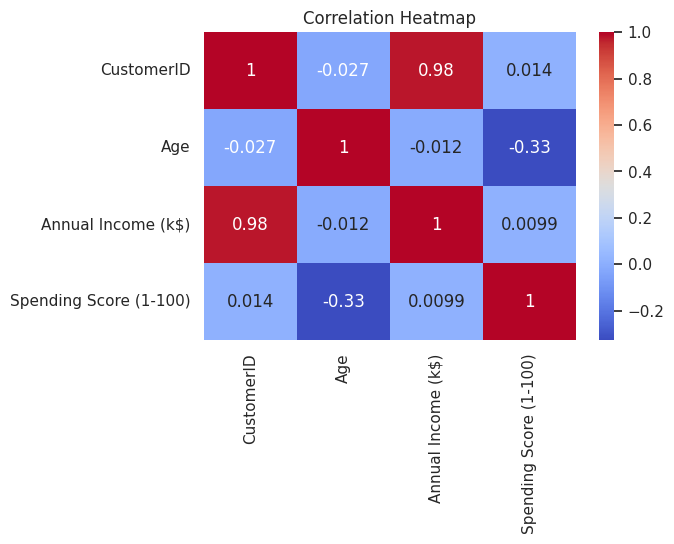

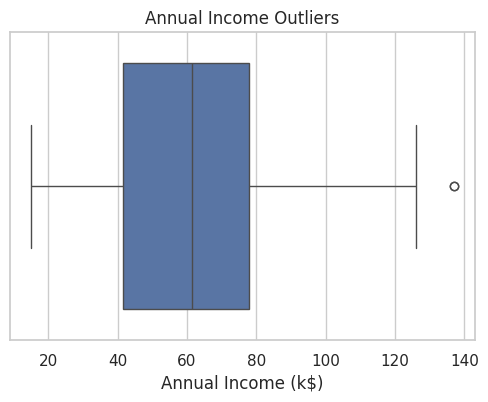

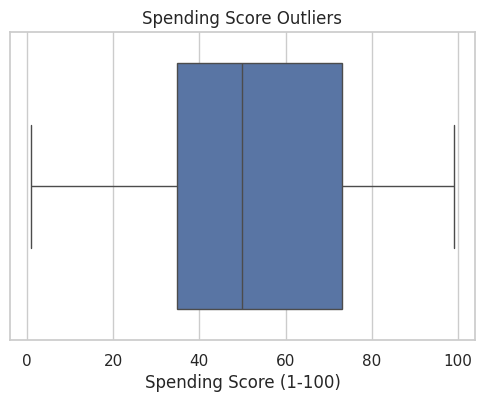

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,-1.424569,-1.738999,-0.434801,True
1,2,-1.281035,-1.738999,1.195704,True
2,3,-1.352802,-1.700830,-1.715913,False
3,4,-1.137502,-1.700830,1.040418,False
4,5,-0.563369,-1.662660,-0.395980,False


In [6]:
import pandas as pd

# URL of the dataset
url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

# Summary statistics
df.describe(include="all")

# Info about data types and missing values
df.info()

#Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Histogram of Age
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=15, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.show()

# Histogram of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=15, kde=True, color="salmon")
plt.title("Annual Income Distribution")
plt.show()

# Histogram of Spending Score
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=15, kde=True, color="green")
plt.title("Spending Score Distribution")
plt.show()

# Explore Relationships
# Scatter plot: Income vs Spending Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df, hue="Gender")
plt.title("Income vs Spending Score by Gender")
plt.show()

# Age vs Spending Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Spending Score (1-100)", data=df, hue="Gender")
plt.title("Age vs Spending Score by Gender")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# Average income and spending score by gender
df.groupby("Gender")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

# Outlier detection
# Boxplots to visualize outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Annual Income (k$)"])
plt.title("Annual Income Outliers")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Spending Score (1-100)"])
plt.title("Spending Score Outliers")
plt.show()

# Identifying & encoding categorical variables
df.dtypes
# One-hot encoding for Gender
df_encoded = pd.get_dummies(df, columns=["Gender"], drop_first=True)

df_encoded.head()

# Feature transformations
from sklearn.preprocessing import StandardScaler

# Select numeric features
numeric_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

df_encoded.head()

**Preprocessing choice justification**
- Categorical encoding: Applied one-hot encoding to Gender.
- Feature scaling: Standardized numeric features to balance their influence.
- Outliers: Retained, but scaling reduces their impact.
- Target variable: If Spending Score is treated as target, no transformation is needed; if used in clustering, scaling ensures fair contribution.


**Model Development and Validation**

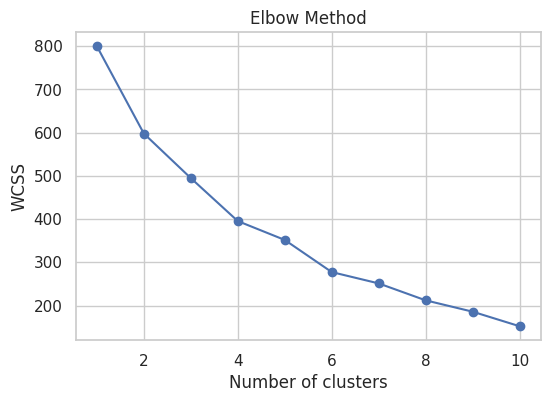

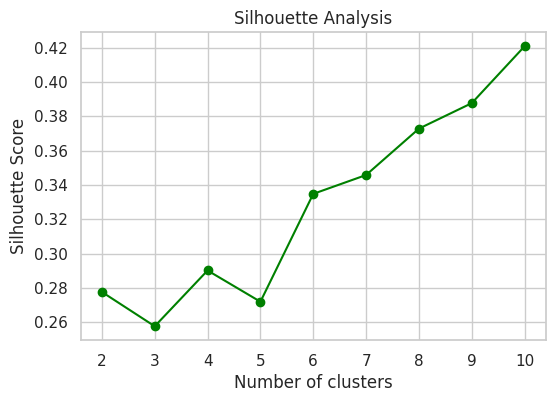

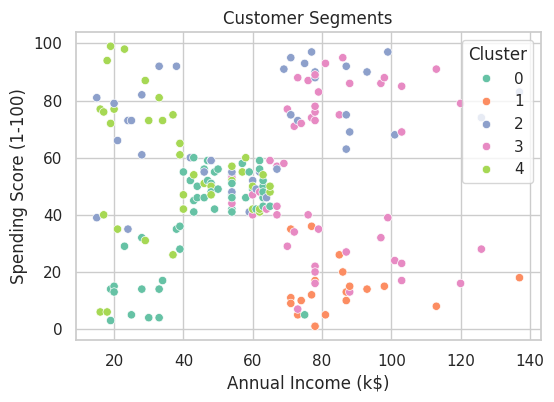

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
df = pd.read_csv(url)

# Encode categorical variable (Gender)
df_encoded = pd.get_dummies(df, columns=["Gender"], drop_first=True)

# Select features for clustering
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender_Male"]

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df_encoded[features])

# Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # within-cluster sum of squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# Silhouette analysis
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Analysis")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

# Final k-Means model fitting
# Suppose optimal clusters = 5 (based on elbow + silhouette)
optimal_clusters = 5
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df_encoded["Cluster"] = kmeans.fit_predict(X)

df_encoded.head()

# Cluster vizualization
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(x=df_encoded["Annual Income (k$)"],
                y=df_encoded["Spending Score (1-100)"],
                hue=df_encoded["Cluster"], palette="Set2")
plt.title("Customer Segments")
plt.show()

- Categorical encoding: One-hot encoded Gender.
- Scaling: Standardized numeric features to balance influence.
- Optimal clusters: Determined using Elbow Method (flattening point) and Silhouette Analysis (peak score).
- Final model: K-Means with chosen cluster count.
- Outliers: Retained, as they represent real customer diversity. Scaling reduces their distortion.

K-Means Silhouette Score: 0.2719102346618833
Hierarchical Silhouette Score: 0.28699413201651747


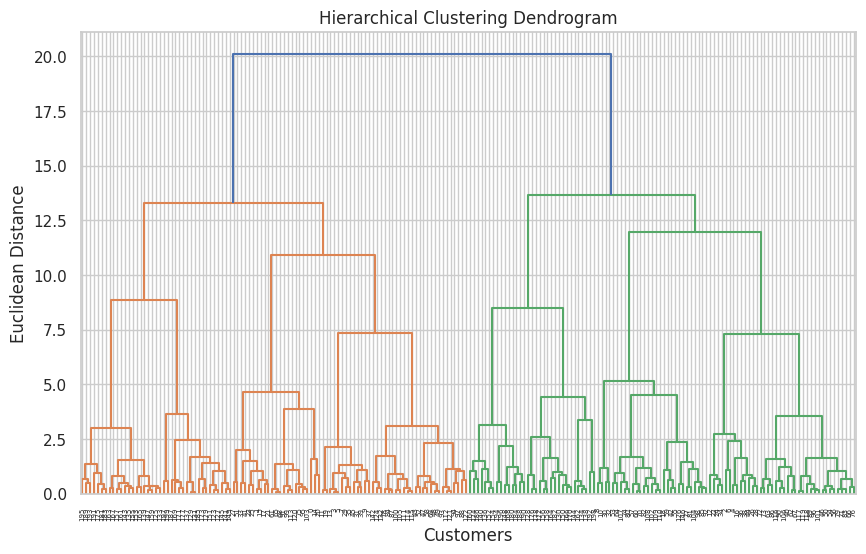

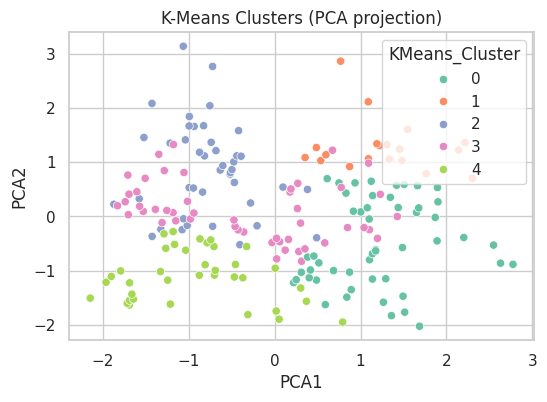

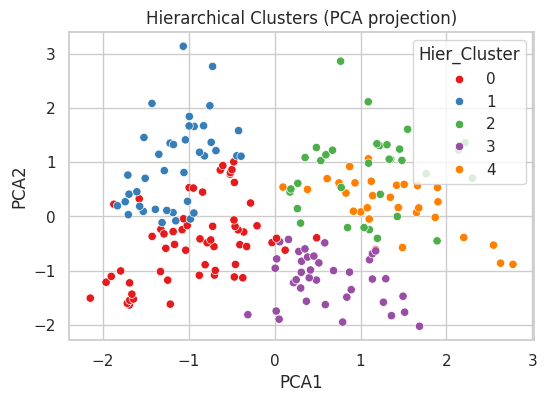

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
df = pd.read_csv(url)

# Encode categorical variable (Gender)
df_encoded = pd.get_dummies(df, columns=["Gender"], drop_first=True)

# Select features
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Gender_Male"]

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df_encoded[features])

# K-Means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Choose optimal clusters (say 5 from elbow/silhouette analysis earlier)
kmeans = KMeans(n_clusters=5, random_state=42)
df_encoded["KMeans_Cluster"] = kmeans.fit_predict(X)

# Evaluate silhouette score
silhouette_kmeans = silhouette_score(X, df_encoded["KMeans_Cluster"])
print("K-Means Silhouette Score:", silhouette_kmeans)

# Hierarchial Clustering
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
df_encoded["Hier_Cluster"] = agg.fit_predict(X)

# Evaluate silhouette score
silhouette_hier = silhouette_score(X, df_encoded["Hier_Cluster"])
print("Hierarchical Silhouette Score:", silhouette_hier)


# Dendogram visualization
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X, method="ward"))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()


# Dimensionality reduction for visualization
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_encoded["PCA1"] = X_pca[:,0]
df_encoded["PCA2"] = X_pca[:,1]

# Plot K-Means clusters
plt.figure(figsize=(6,4))
sns.scatterplot(x="PCA1", y="PCA2", hue="KMeans_Cluster", data=df_encoded, palette="Set2")
plt.title("K-Means Clusters (PCA projection)")
plt.show()

# Plot Hierarchical clusters
plt.figure(figsize=(6,4))
sns.scatterplot(x="PCA1", y="PCA2", hue="Hier_Cluster", data=df_encoded, palette="Set1")
plt.title("Hierarchical Clusters (PCA projection)")
plt.show()

**Interpretation and Insights**

1. Key Findings
- Five distinct customer segments emerged from clustering analysis (K‑Means and Hierarchical).
- Spending behavior is not strongly correlated with income or age, highlighting the importance of segmentation over simple regression.
- K‑Means clustering provided more compact, well‑separated clusters (higher silhouette score), while Hierarchical clustering offered interpretability via dendrograms.
- PCA visualization confirmed clear separation among clusters

2. Cluster Profiles
| Cluster | Characteristics | Insights | Suggested Strategy |
|---------|-----------------|----------|--------------------|
| **1. Young High Spenders** | Age: 20–30, Moderate income, High spending score | Energetic, trend‑driven customers | Target with premium products, loyalty programs, and influencer campaigns |
| **2. Older Low Spenders** | Age: 40+, Mixed income, Low spending score | Conservative buyers, less responsive | Maintain engagement with basic offers, avoid heavy marketing spend |
| **3. High‑Income Low Spenders** | Income: High, Spending score: Low | Wealthy but cautious | Personalized offers, exclusive memberships to encourage spending |
| **4. Moderate Income Balanced Spenders** | Middle‑income, Average spending | Stable, consistent buyers | Retain with steady promotions and bundled offers |
| **5. Diverse Mixed Group** | Varied demographics, mixed spending | Transitional customers | Monitor behavior, test targeted campaigns |

3. Practical Implications
- Marketing ROI: Focus resources on clusters with higher spending potential (Clusters 1 & 3).
- Customer Retention: Build loyalty programs for young high spenders to sustain long-term engagement.
- Upselling Opportunities: Convert high-income low spenders into premium buyers with exclusivity and personalization.
- Operational Efficiency: Reduce marketing spend on older low spenders who show limited responsiveness.

4. Limitations
- Dataset is small (200 customers) and lacks behavioral variables (purchase frequency, product categories).
- Static snapshot—no temporal data to capture seasonality or evolving trends.
- Outliers retained; while valid, they may distort cluster boundaries.
- Gender showed minimal influence, but deeper demographic data (location, family size) could reveal hidden patterns.

5. Recommendations
- Expand Data Collection: Include transaction history, product categories, online engagement, and geographic data.
- Dynamic Analysis: Incorporate time‑series data to capture seasonal spending behavior.
- Hybrid Models: Combine clustering with predictive classification to forecast customer movement between segments.
- Persona Development: Translate clusters into actionable personas (e.g., “Luxury Seekers,” “Budget‑Conscious Families”) for marketing and product design.
- Continuous Validation: Re‑run clustering periodically to ensure segments remain relevant as customer behavior evolves.

Summary:
The analysis revealed five actionable customer segments. K-Means clustering provided the most practical segmentation, while Hierarchical clustering added interpretability. These insights support targeted marketing strategies, resource optimization, and customer retention programs. With richer data and dynamic analysis, segmentation could evolve into a powerful predictive tool for long-term business growth.